<a href="https://colab.research.google.com/github/sarunsmenon/tf_kaggle/blob/sarunsmenon/100_Basic_Chart_Identifier_Model_PyT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Libraries

In [55]:
! pip install --upgrade torchvision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 38.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.2/670.2 MB 924.6 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 36.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 51.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 53.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 10.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.8/209.8 MB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import torch
import torchvision
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder

from torch.utils.data import Subset, Dataset
from sklearn.model_selection import train_test_split
from collections import Counter
from torch.utils.data import DataLoader

from google.colab import drive
from google.colab import data_table
data_table.enable_dataframe_formatter()

# Define Variables

In [2]:
folder_path = 'drive/MyDrive/Kaggle/benetech-making-graphs-accessible/train/images_sample'
model_path = 'drive/MyDrive/Kaggle/benetech-making-graphs-accessible/model/'

In [3]:
batch_size = 32
img_height = 120
img_width = 300
seed=2011
sample_size = 5000
image_size = (img_height, img_width)

In [4]:
valid_split = 0.3 # keeps 70% of data for training

# Define Training and Validation dataset

In [27]:
class SubSetTransformer(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
      x, y = self.subset[index]
      #print(f"index is {index} and x is {x} and y is {y}")
      if self.transform:
          x = self.transform(x)
          #print(f"transformed x is {x}")
      return x, y

    def __len__(self):
        return len(self.subset)


In [76]:
train_transformer = v2.Compose([
    v2.ToImage(),
    v2.Resize(image_size,antialias=True),
    v2.RandomHorizontalFlip(0.2),
    v2.RandomVerticalFlip(0.1),
    v2.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    v2.RandomInvert(0.2),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])


non_train_transformer = v2.Compose([
    v2.ToImage(),
    v2.Resize(image_size,antialias=True),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

In [29]:
all_data = ImageFolder(root=folder_path)

In [73]:
class_names = all_data.class_to_idx
print(class_names)

{'bar_chart': 0, 'dot_chart': 1, 'line_chart': 2, 'scatter_chart': 3}


In [74]:
class_map = {}
for k,v in class_names.items():
  class_map[v]=k

class_map

{0: 'bar_chart', 1: 'dot_chart', 2: 'line_chart', 3: 'scatter_chart'}

In [32]:
train_indices, holdout_indices, train_targets, holdout_targets = train_test_split(
    range(len(all_data)),
    all_data.targets,
    stratify=all_data.targets,
    test_size=valid_split,
    random_state=1
)

train_dataset = Subset(all_data, train_indices)
holdout_dataset = Subset(all_data, holdout_indices)

train_indices, val_indices, _, _ = train_test_split(
    train_indices,
    train_targets,
    stratify=train_targets,
    test_size=0.2,
    random_state=1
)

# this way of sampling does not work because the transformations are differnt for each train, valid and holdout dataset

# train_sampler = torch.utils.data.SubsetRandomSampler(train_indices)
# valid_sampler = torch.utils.data.SubsetRandomSampler(val_indices)
# holdout_sampler = torch.utils.data.SubsetRandomSampler(holdout_indices)

# train_loader = torch.utils.data.DataLoader(all_data, batch_size=batch_size, sampler=train_sampler)
# valid_loader = torch.utils.data.DataLoader(all_data, batch_size=batch_size, sampler=valid_sampler)
# holdout_loader = torch.utils.data.DataLoader(all_data, batch_size=batch_size, sampler=holdout_sampler)


train_dataset = Subset(all_data, train_indices)
val_dataset =  Subset(all_data, val_indices)


In [33]:
train_ds = SubSetTransformer(subset=train_dataset, transform=train_transformer)
val_ds = SubSetTransformer(subset=val_dataset, transform=non_train_transformer)
holdout_ds = SubSetTransformer(subset=holdout_dataset, transform=non_train_transformer)

In [54]:
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=True)
holdout_loader = DataLoader(holdout_ds, batch_size=batch_size, shuffle=True)


# Visualise Images

Text(0.5, 1.0, 'line_chart')

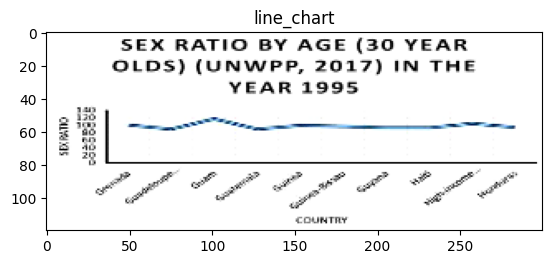

In [77]:
import matplotlib.pyplot as plt
single_batch = next(iter(train_loader))
# Selecting the first image tensor from the batch.
img_index = 11
single_image = single_batch[0][img_index]
single_image.shape
plt.imshow(single_image.permute(1, 2, 0))
plt.title(class_map[single_batch[1].numpy()[img_index]])

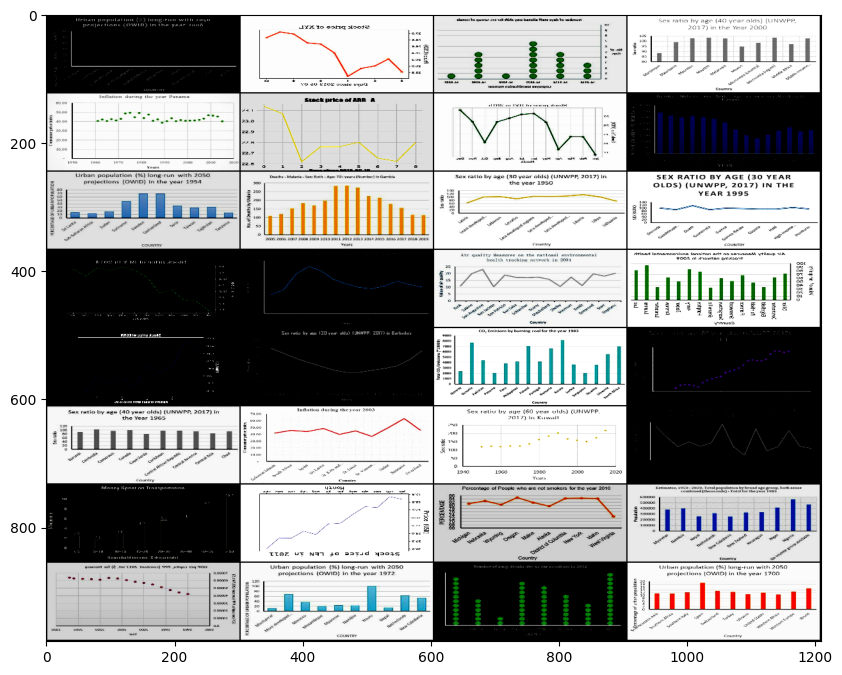

In [80]:
single_batch_grid = torchvision.utils.make_grid(single_batch[0], nrow=4)
plt.figure(figsize = (10,10))
plt.imshow(single_batch_grid.permute(1, 2, 0))

# Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential(
  [
    layers.BatchNormalization(),
    layers.RandomTranslation(
                              height_factor=(-0.2, 0.3),
                              width_factor=(-0.2, 0.3),
                              fill_mode='reflect',
                              interpolation='bilinear',
                              seed=seed,
                              fill_value=0.0
                            ),
    layers.RandomFlip("horizontal_and_vertical",
                      input_shape=(img_height,
                                  img_width,
                                  3)),
    layers.RandomRotation(40),
    layers.RandomZoom(0.1)
  ]
)

In [ ]:
train_ds = train_ds.map(
    lambda img, label: (data_augmentation(img), label),
    num_parallel_calls=tf.data.AUTOTUNE,
)
# Prefetching samples in GPU memory helps maximize GPU utilization.
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

# Model Build

## Efficient net Model build

In [ ]:
conv_base = tf.keras.applications.efficientnet_v2.EfficientNetV2B2(weights="imagenet", include_top=False)
conv_base.trainable = False

model = models.Sequential()
model.add(data_augmentation)
model.add(conv_base)
model.add(layers.GlobalMaxPooling2D(name="gap"))
model.add(layers.Dense(512, activation='relu'))
#avoid overfitting
model.add(layers.Dropout(rate=0.2, name="dropout_out"))
# Set NUMBER_OF_CLASSES to the number of your final predictions.
model.add(layers.Dense(NUMBER_OF_CLASSES, activation="softmax", name="fc_out"))
model.compile(loss='binary_crossentropy',optimizer=optimizers.RMSprop(learning_rate=1e-4),metrics=['acc'])

35839040/35839040 [==============================] - 0s 0us/step


## Basic Model Build

In [ ]:
model = models.Sequential()

model.add(data_augmentation)

model.add(layers.Conv2D(filters=32,kernel_size=3, activation='relu',input_shape=[img_height,img_width,3]))
model.add(layers.MaxPool2D(pool_size=2, strides=2))

model.add(layers.Conv2D(filters=32,kernel_size=3, activation='relu'))
model.add(layers.MaxPool2D(pool_size=2, strides=2))

model.add(layers.Flatten())

model.add(layers.Dense(units=128, activation='relu'))

model.add(layers.Dense(units=128, activation='relu'))

model.add(layers.Dense(NUMBER_OF_CLASSES, activation="softmax", name="fc_out"))

In [ ]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 118, 298, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 59, 149, 32)      0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 57, 147, 32)       9248      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 28, 73, 32)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 65408)             0         
                                                                 
 dense (Dense)               (None, 128)              

## Keras Recommended Model Build - https://keras.io/examples/vision/image_classification_from_scratch/

In [ ]:
def make_model(input_shape, num_classes):

  inputs = keras.Input(shape=input_shape)

  # Entry block
  x = layers.Rescaling(1.0 / 255)(inputs)
  x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation("relu")(x)
  previous_block_activation = x

  for size in [256, 512, 728]:
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(filters = size, kernel_size=3, padding="same")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(filters = size, kernel_size=3, padding="same")(x)
    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

    # Project residual
    residual = layers.Conv2D(size, 1, strides=2, padding="same")(previous_block_activation)

    x = layers.add([x, residual])  # Add back residual
    previous_block_activation = x  # Set aside next residual

  x = layers.SeparableConv2D(1024, 3, padding="same",activation='relu')(x)
  x = layers.BatchNormalization()(x)

  x = layers.GlobalAveragePooling2D()(x)
  if num_classes == 2:
      activation = "sigmoid"
      units = 1
  else:
      activation = "softmax"
      units = num_classes

  x = layers.Dropout(0.5)(x)
  outputs = layers.Dense(units, activation=activation)(x)
  return tf.keras.Model(inputs, outputs)


model = make_model(input_shape=image_size + (3,), num_classes=len(class_names))
tf.keras.utils.plot_model(model, show_shapes=True)


NameError: ignored

# Train Model

In [ ]:
model.compile(
    loss="categorical_crossentropy",
    optimizer=keras.optimizers.Adam(1e-3),
    metrics=["accuracy"],
)

epochs = 25

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("save_at_{epoch}.keras"),
]

In [ ]:
%%time

history = model.fit(
  train_ds,
  validation_data=val_ds,
  callbacks=callbacks,
  epochs=epochs
)

Epoch 1/25
133/133 [==============================] - 744s 5s/step - loss: 0.8080 - accuracy: 0.6950 - val_loss: 1.7544 - val_accuracy: 0.3977
Epoch 2/25
133/133 [==============================] - 74s 548ms/step - loss: 0.4698 - accuracy: 0.8165 - val_loss: 2.7682 - val_accuracy: 0.3977
Epoch 3/25
133/133 [==============================] - 74s 544ms/step - loss: 0.3651 - accuracy: 0.8604 - val_loss: 2.8903 - val_accuracy: 0.3977
Epoch 4/25
133/133 [==============================] - 73s 544ms/step - loss: 0.2948 - accuracy: 0.8807 - val_loss: 1.7896 - val_accuracy: 0.4143
Epoch 5/25
133/133 [==============================] - 74s 548ms/step - loss: 0.2776 - accuracy: 0.8842 - val_loss: 1.2692 - val_accuracy: 0.5541
Epoch 6/25
133/133 [==============================] - 74s 551ms/step - loss: 0.2690 - accuracy: 0.8903 - val_loss: 0.4402 - val_accuracy: 0.8353
Epoch 7/25
133/133 [==============================] - 73s 544ms/step - loss: 0.2262 - accuracy: 0.9075 - val_loss: 0.6862 - val_accu

In [ ]:
import pickle
file = open(model_path+'Basic_Chart_Identifier_Model_sample_0.2.pkl', 'wb')
pickle.dump(model, file)
file.close()


file = open(model_path+'Basic_Chart_Identifier_Model_sample_0.2_history.pkl', 'wb')
pickle.dump(history, file)
file.close()


<Axes: >

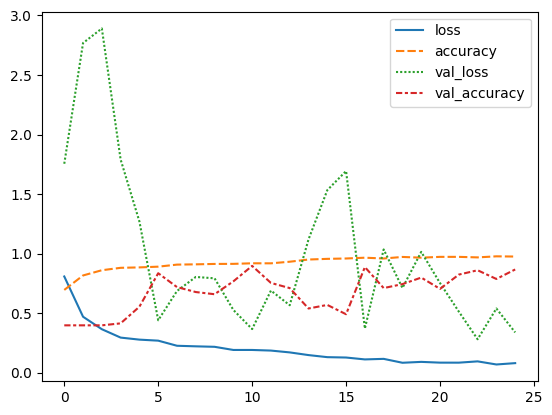

In [ ]:
history_dict = history.history

history_metrics = pd.DataFrame({'loss':history_dict['loss'],
                                'accuracy':history_dict['accuracy'],
                                'val_loss':history_dict['val_loss'],
                                'val_accuracy':history_dict['val_accuracy']
                                })

sns.lineplot(data=history_metrics)

# Inference

In [ ]:
model = pickle.load(open(model_path+'Basic_Chart_Identifier_Model_sample_0.2.pkl', 'rb'))

## Predictions

In [ ]:
predictions = model.predict(test_ds,batch_size=batch_size)
pred_df = pd.DataFrame(predictions)

38/38 [==============================] - 6s 145ms/step


In [ ]:
max_columns = pred_df.idxmax(axis=1)
pred_df['max_col_name'] = max_columns
pred_df['pred_label'] = pred_df['max_col_name'].apply(lambda index: class_names[index])

## True Labels

In [ ]:
labels_lst = []
for images, labels in test_ds:
  labels_lst.append(pd.DataFrame(labels))

In [ ]:
true_labels_df = pd.concat(labels_lst).reset_index(drop=True)
max_columns = true_labels_df.idxmax(axis=1)
true_labels_df['max_col_name'] = max_columns
true_labels_df['true_label'] = true_labels_df['max_col_name'].apply(lambda index: class_names[index])

# Evaluation

In [ ]:
y_true = true_labels_df['true_label']
y_pred = pred_df['pred_label']

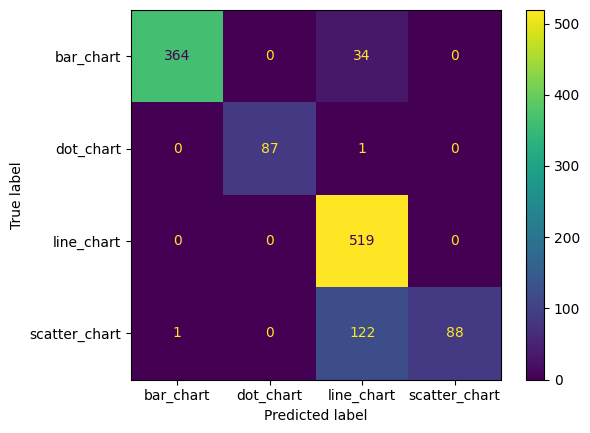

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred, labels=class_names
)

In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))

               precision    recall  f1-score   support

    bar_chart       1.00      0.91      0.95       398
    dot_chart       1.00      0.99      0.99        88
   line_chart       0.77      1.00      0.87       519
scatter_chart       1.00      0.42      0.59       211

     accuracy                           0.87      1216
    macro avg       0.94      0.83      0.85      1216
 weighted avg       0.90      0.87      0.86      1216



# Inference on one image

In [ ]:
img = keras.utils.load_img('drive/MyDrive/Kaggle/benetech-making-graphs-accessible/train/images/bar_chart/0a5b952cfbdf.jpg', target_size=image_size)
img_array = keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

img_predictions = model.predict(img_array)


1/1 [==============================] - 1s 667ms/step


In [ ]:
pred_label = class_names[np.argmax(np.round(img_predictions,2))]
print(" Predicted label is :: "+ pred_label)

 Predicted label is :: bar_chart


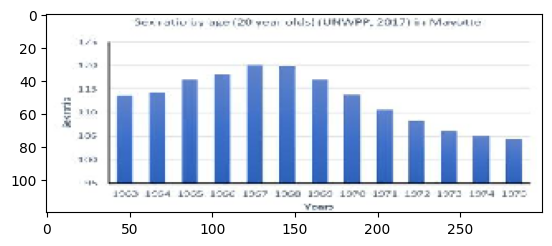

In [ ]:
plt.imshow(img)